# Optimización de costos en microrred aislada con generadores diesel y FV
**MILP, UC**  
Scheduling óptimo con Pyomo. Tiempos mínimos de uptime y downtime, linealización de costo de combustible basada en Parisio y restricciones de rampa.

Adaptado a PYOMO desde la implementación original en [https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html](https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html) y en el Ejemplo 12.15 del libro [Model Building in Mathematical Programming](https://share.google/ovWcmGq54LiyOcWm8) de H. Paul Williams (5ª edición, págs. 270-271 y 325-326).

Formulación MILP con:
- Satisfacción exacta de la demanda neta (demanda menos generación FV) por período
- Restricción de reserva operativa (15% sobre la demanda neta)
- Costos fijos por generador activo, costos marginales y costos de arranque
- Objetivo: minimizar costo total de operación

V2: El problema de Williams de despacho nacional (≈ 45 GW) ha sido redimensionado a escala de microrred (≈ 2.1 MW pico), reemplazando los generadores térmicos convencionales por generadores diesel. Se implementan las siguientes extensiones respecto a la formulación original:

- Costos fijos de O&M (Operation and Maintenance) por generador activo
- Linealización Parisio de la curva cuadrática de costo de combustible
- Costos de apagado (`shutdown_cost`)
- Tiempos mínimos de encendido y apagado (`min_up_time`, `min_down_time`)

V3: Se pasa de una representación agregada de la demanda en 5 bloques horarios a una discretización horaria completa (24 períodos), lo cual permite capturar con mayor fidelidad las rampas de demanda, especialmente en los períodos de transición (mañana y tarde).

V4: Se agregan **restricciones de rampa** (ramp-up y ramp-down) para limitar la tasa de cambio de producción entre períodos consecutivos. Las restricciones se formulan de manera trivialmente satisfecha (ramp_limit = Pmax) dado que los generadores diesel tienen una dinámica de carga mucho más rápida que el paso de tiempo de 1 hora.

V5: Se incorpora un **generador fotovoltaico (GFV)** modelado con el enfoque de Loyarte (tesis doctoral, 2019). La generación solar se trata como fuente no controlable: su producción horaria se calcula en pre-proceso y se sustrae de la demanda bruta antes de resolver el Unit Commitment. Los datos de irradiancia y temperatura corresponden al parque solar de la UTN FR Santa Fe, día 01/01/2019 (promedios horarios).

## Problema: Gestión Energética de Microrred con DDG + GFV

Una flota de 27 grupos generadores diesel está disponible para satisfacer la demanda eléctrica de una microrred aislada a lo largo de un día. Hay tres tipos de unidades diesel disponibles. Cada generador opera entre un nivel mínimo (50% de capacidad nominal) y un nivel máximo. Existen costos de O&M (operación y mantenimiento) fijos, costos de combustible (modelados con curva cuadrática linealizada), costos de arranque y de apagado. Cada unidad debe permanecer encendida/apagada un tiempo mínimo tras cada transición de estado.

Además, se dispone de un **generador fotovoltaico de 400 kWp** (1000 módulos × 400 Wp). Al ser una fuente no gestionable (no controlable), su producción horaria $P^{\mathrm{PV}}_t$ se calcula en pre-proceso mediante el modelo de Loyarte y se descuenta de la demanda bruta. Los generadores diesel deben cubrir únicamente la **demanda neta**:

$$D^{\mathrm{net}}_t = D_t - P^{\mathrm{PV}}_t \geq 0 \qquad \forall t \in T$$

Los datos de demanda durante las 24 horas y las características de los generadores se muestran en la sección **Carga de datos**.

La capacidad total instalada diesel es 2.730 kW (12×40 + 10×100 + 5×250). Considerando la reserva del 15% sobre la demanda neta, la flota diesel es siempre suficiente.

¿Qué generadores deberían estar funcionando en qué períodos para minimizar el costo total de operación?

### Notas sobre la configuración

- Capacidades (min/max_output): límite mínimo de generación en el 50% de la capacidad nominal, siguiendo las recomendaciones de Nemati et al. para garantizar eficiencia operativa aceptable.
- Costos de O&M (`cost_per_hour`): consumo fijo en vacío más mantenimiento (parámetro $c$ de Nemati). *No incluye combustible*, que se modela por separado con la curva cuadrática.
- Costos de combustible: curva $f(P) = a P^2 + b P$ [$/h] linealizada con 3 segmentos (enfoque Parisio).
- Costos de apagado (`shutdown_cost`): fijado en el 50% del costo de arranque (Nemati et al.).
- Tiempos mínimos: 1 hora para evitar ciclado excesivo (Parisio, 2014).
- **Límite de rampa (`ramp_limit`):** fijado en `max_output` (trivialmente satisfecho), dado que los generadores diesel alcanzan carga completa en minutos, mucho más rápido que el paso de tiempo de 1 hora.
- **Generador fotovoltaico:** 1000 módulos de 400 Wp (400 kWp nominales). Modelo Loyarte con $k_p = -0{,}0045\,°\mathrm{C}^{-1}$, $\eta = 0{,}92$, $T_r = 25\,°\mathrm{C}$, $G_{\mathrm{std}} = 1000\,\mathrm{W/m^2}$. Datos de irradiancia y temperatura: UTN FR Santa Fe, 01/01/2019.

## Linealización de la Curva de Costo de Combustible
### Enfoque Parisio (2014)

Dado que los MILP son computacionalmente más eficientes que los MIQP, la función de costo de combustible de un generador DDG

$$f(P) = a P^2 + b P \quad [\text{\$/h}]$$

se aproxima por el máximo de funciones afines sin introducir variables binarias adicionales:

$$f(P) \approx \sigma = \max_{j=1,\dots,n}\{S_j P + s_j\}$$

donde los coeficientes de cada segmento $j$ se obtienen evaluando la tangente de $f$ en el punto de soporte $P_j$:

$$S_j = f'(P_j) = 2aP_j + b \qquad s_j = f(P_j) - S_j P_j = -aP_j^2$$

Extensión a clases de generadores (formulación agregada): si hay $n_{g,t}$ unidades activas de la clase $g$ produciendo $x_{g,t}$ kW en total, el costo de combustible agregado es:

$$n_{g,t} \cdot f\!\left(\frac{x_{g,t}}{n_{g,t}}\right) = a\frac{x_{g,t}^2}{n_{g,t}} + b\, x_{g,t}$$

Con la aproximación lineal tangente en cada punto de soporte, esto se convierte en el conjunto de restricciones lineales:

$$\sigma_{g,t} \geq S_j \cdot x_{g,t} + s_j \cdot n_{g,t} \qquad \forall j = 1, \dots, n_{\mathrm{seg}}$$

Esta formulación es lineal porque $S_j$ y $s_j$ son constantes, $x_{g,t}$ es continua y $n_{g,t}$ es entera.

In [49]:
import pyomo.environ as pe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

## Creación de Archivos de Datos

Las siguientes celdas generan los archivos CSV con los parámetros de la microrred. Si ya existen, los sobreescribe.

In [50]:
os.makedirs("data", exist_ok=True)

# ── Generadores diesel ────────────────────────────────────────────────────────
# ramp_limit = max_output (restricción trivialmente satisfecha; diesel cicla en minutos)
generators_csv = """generator_class,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,ramp_limit,state0
diesel_small,12,20.0,40.0,2.5,5.0,2.5,1,1,40.0,0
diesel_med,10,50.0,100.0,5.8,12.0,6.0,1,1,100.0,0
diesel_large,5,125.0,250.0,14.5,25.0,12.5,1,1,250.0,0
"""

with open("data/generators_diesel.csv", "w") as f:
    f.write(generators_csv)

# ── Datos solares: irradiancia y temperatura horaria ─────────────────────────
# Fuente: Parque solar UTN FR Santa Fe, 01/01/2019 (promedio horario de datos cada 10 min)
solar_csv = """hora,irradiancia,temperatura
0,0.0,27.9
1,0.0,27.55
2,0.0,27.17
3,0.0,26.81
4,0.0,26.48
5,0.0,26.13
6,16.0,26.36
7,89.16,27.53
8,335.67,29.08
9,540.83,32.1
10,679.33,32.4
11,990.67,33.98
12,773.17,35.03
13,739.0,34.73
14,196.5,30.81
15,747.17,32.45
16,668.67,33.65
17,402.33,32.86
18,88.67,31.15
19,51.17,29.46
20,5.17,26.98
21,0.0,28.15
22,0.0,28.67
23,0.0,28.5
"""

with open("data/solar_utn_santafe.csv", "w") as f:
    f.write(solar_csv)

# ── Demanda horaria ────────────────────────────────────────────────────────────
# (La demanda neta se calculará tras aplicar el modelo PV)
demand_hourly = [
    820, 790, 810, 800, 830, 870,   # 00–05: valle nocturno
   1050,1380,1575,1420,1350,1380,   # 06–11: rampa matutina y mañana
   1520,1480,1400,1620,1850,2050,   # 12–17: tarde y rampa vespertina
   2100,1980,1750,1550,1350,1100,   # 18–23: pico y descenso nocturno
]

import datetime
base = datetime.datetime(2024, 1, 1, 0, 0, 0)
rows = []
for h, d in enumerate(demand_hourly):
    ts  = base + datetime.timedelta(hours=h)
    rows.append(f"{ts},{d}")

time_periods_csv  = "time_period,expected_demand\n"
time_periods_csv += "\n".join(rows) + "\n"

with open("data/time_periods.csv", "w") as f:
    f.write(time_periods_csv)

print("Archivos CSV creados:")
print("   data/generators_diesel.csv  (3 clases, ramp_limit = Pmax)")
print("   data/solar_utn_santafe.csv  (irradiancia y temperatura horaria, UTN FR Santa Fe, 01/01/2019)")
print("   data/time_periods.csv       (24 períodos horarios, demanda bruta)")
print()
print(f"  Demanda mínima  : {min(demand_hourly):>6} kW  (hora {demand_hourly.index(min(demand_hourly)):02d}:00)")
print(f"  Demanda máxima  : {max(demand_hourly):>6} kW  (hora {demand_hourly.index(max(demand_hourly)):02d}:00)")
print(f"  Demanda media   : {sum(demand_hourly)/len(demand_hourly):>6.0f} kW")
print()
print("Capacidad total instalada diesel:")
print(f"  diesel_small : 12 × 40  kW = {12*40:>5} kW")
print(f"  diesel_med   : 10 × 100 kW = {10*100:>5} kW")
print(f"  diesel_large :  5 × 250 kW = {5*250:>5} kW")
print(f"  TOTAL        :             = {12*40+10*100+5*250:>5} kW")

Archivos CSV creados:
   data/generators_diesel.csv  (3 clases, ramp_limit = Pmax)
   data/solar_utn_santafe.csv  (irradiancia y temperatura horaria, UTN FR Santa Fe, 01/01/2019)
   data/time_periods.csv       (24 períodos horarios, demanda bruta)

  Demanda mínima  :    790 kW  (hora 01:00)
  Demanda máxima  :   2100 kW  (hora 18:00)
  Demanda media   :   1368 kW

Capacidad total instalada diesel:
  diesel_small : 12 × 40  kW =   480 kW
  diesel_med   : 10 × 100 kW =  1000 kW
  diesel_large :  5 × 250 kW =  1250 kW
  TOTAL        :             =  2730 kW


## Modelo de Generador Fotovoltaico
### Enfoque Loyarte (tesis doctoral, 2019)

La potencia eléctrica entregada por un GFV con $N$ módulos idénticos operando en MPP (Maximum Power Point) es:

$$P_{\mathrm{PV}}[kW] = N \cdot \frac{G}{G_{\mathrm{std}}} \cdot P_{\mathrm{pico}} \cdot \bigl[1 + k_p \cdot (T_c - T_r)\bigr] \cdot \eta \cdot 10^{-3} \tag{1}$$

donde la temperatura de celda se estima a partir de la temperatura ambiente y la irradiancia incidente (modelo simplificado sin viento):

$$T_c = T + 0{,}031\,[°C \cdot m^2/W] \cdot G \tag{2}$$

**Parámetros del GFV modelado:**

| Parámetro | Símbolo | Valor | Unidad | Descripción |
|:---|:---:|---:|:---:|:---|
| Módulos instalados | $N$ | 1 000 | — | Cantidad de paneles |
| Potencia pico por módulo | $P_{\mathrm{pico}}$ | 400 | W | Módulo policristalino típico |
| Potencia nominal total | — | 400 | kWp | $N \times P_{\mathrm{pico}} \times 10^{-3}$ |
| Irradiancia estándar | $G_{\mathrm{std}}$ | 1 000 | W/m² | Condición STC fabricante |
| Temperatura de referencia | $T_r$ | 25 | °C | Condición STC fabricante |
| Coeficiente temp.-potencia | $k_p$ | −0,0045 | °C⁻¹ | Pérdida ≈ 0,45 %/°C (Si policrist.) |
| Rendimiento global | $\eta$ | 0,92 | p.u. | Incluye inversor y pérdidas BOS |

> **Nota:** Como se indica en Loyarte, las mediciones de irradiancia de la estación meteorológica se toman sobre superficie horizontal. En este ejercicio se asume, por simplicidad, que los valores corresponden directamente a $G$ (irradiancia normal a los módulos).

In [51]:
# ── Parámetros del GFV (Loyarte) ─────────────────────────────────────────────
PV_N      = 1000    # módulos
PV_Ppico  = 400     # W por módulo
PV_kp     = -0.0045 # °C⁻¹ coeficiente temperatura-potencia
PV_Tr     = 25.0    # °C temperatura de referencia
PV_Gstd   = 1000.0  # W/m² irradiancia estándar
PV_eta    = 0.92    # rendimiento global (inversor + BOS)

def loyarte_pv(G, T_amb, N=PV_N, Ppico=PV_Ppico, kp=PV_kp,
               Tr=PV_Tr, Gstd=PV_Gstd, eta=PV_eta):
    """Modelo Loyarte (ec. 1-2). Retorna P_PV en kW."""
    if G <= 0:
        return 0.0
    Tc = T_amb + 0.031 * G                           # ec. (2): temperatura de celda
    P  = N * (G / Gstd) * Ppico * (1 + kp*(Tc-Tr)) * eta * 1e-3  # ec. (1): potencia [kW]
    return max(P, 0.0)                               # no puede ser negativa

# ── Carga de datos solares y cálculo del perfil PV ───────────────────────────
solar_data = pd.read_csv("data/solar_utn_santafe.csv", index_col="hora")

pv_profile = {}
for h in range(24):
    G   = solar_data.loc[h, 'irradiancia']
    T   = solar_data.loc[h, 'temperatura']
    pv_profile[h] = round(loyarte_pv(G, T), 2)

print(f"GFV: {PV_N} módulos × {PV_Ppico} Wp = {PV_N*PV_Ppico/1000:.0f} kWp nominales")
print(f"     kp={PV_kp} °C⁻¹ | η={PV_eta} | Tr={PV_Tr}°C | Gstd={PV_Gstd} W/m²")
print()
print(f"{'Hora':>5} {'G (W/m²)':>10} {'T_amb (°C)':>11} {'T_c (°C)':>10} {'P_PV (kW)':>11}")
print("-" * 50)
for h in range(24):
    G  = solar_data.loc[h, 'irradiancia']
    T  = solar_data.loc[h, 'temperatura']
    Tc = T + 0.031*G if G > 0 else T
    print(f"{h:>5} {G:>10.2f} {T:>11.2f} {Tc:>10.2f} {pv_profile[h]:>11.1f}")
print("-" * 50)
print(f"{'Pico':>5} {'':>10} {'':>11} {'':>10} {max(pv_profile.values()):>11.1f}  kW")
print(f"{'Total':>5} {'':>10} {'':>11} {'':>10} {sum(pv_profile.values()):>11.1f}  kWh/día")

GFV: 1000 módulos × 400 Wp = 400 kWp nominales
     kp=-0.0045 °C⁻¹ | η=0.92 | Tr=25.0°C | Gstd=1000.0 W/m²

 Hora   G (W/m²)  T_amb (°C)   T_c (°C)   P_PV (kW)
--------------------------------------------------
    0       0.00       27.90      27.90         0.0
    1       0.00       27.55      27.55         0.0
    2       0.00       27.17      27.17         0.0
    3       0.00       26.81      26.81         0.0
    4       0.00       26.48      26.48         0.0
    5       0.00       26.13      26.13         0.0
    6      16.00       26.36      26.86         5.8
    7      89.16       27.53      30.29        32.0
    8     335.67       29.08      39.49       115.5
    9     540.83       32.10      48.87       177.7
   10     679.33       32.40      53.46       218.0
   11     990.67       33.98      64.69       299.4
   12     773.17       35.03      59.00       241.0
   13     739.00       34.73      57.64       232.0
   14     196.50       30.81      36.90        68.4
   15   

## Carga de Datos

In [52]:
generator_data = pd.read_csv(
    "data/generators_diesel.csv",
    index_col="generator_class",
)
generator_data

,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,ramp_limit,state0
generator_class,,,,,,,,,,
diesel_small,12,20.0,40.0,2.5,5.0,2.5,1,1,40.0,0
diesel_med,10,50.0,100.0,5.8,12.0,6.0,1,1,100.0,0
diesel_large,5,125.0,250.0,14.5,25.0,12.5,1,1,250.0,0


In [53]:
time_period_data = pd.read_csv(
    "data/time_periods.csv",
    parse_dates=["time_period"],
    index_col="time_period",
)
time_period_data

,expected_demand
time_period,
2024-01-01 00:00:00,820
2024-01-01 01:00:00,790
2024-01-01 02:00:00,810
2024-01-01 03:00:00,800
2024-01-01 04:00:00,830
2024-01-01 05:00:00,870
2024-01-01 06:00:00,1050
2024-01-01 07:00:00,1380
2024-01-01 08:00:00,1575


In [54]:
solar_data_df = pd.read_csv("data/solar_utn_santafe.csv", index_col="hora")
solar_data_df

,irradiancia,temperatura
hora,,
0,0.00,27.90
1,0.00,27.55
2,0.00,27.17
3,0.00,26.81
4,0.00,26.48
5,0.00,26.13
6,16.00,26.36
7,89.16,27.53
8,335.67,29.08


## Conjuntos

In [55]:
GENERATORS   = list(generator_data.index)        # ['diesel_small', 'diesel_med', 'diesel_large']
TIME_PERIODS = list(time_period_data.index)       # lista de timestamps
T            = list(range(len(TIME_PERIODS)))     # índices enteros 0..23 para Pyomo

print(f"Clases de generadores : {GENERATORS}")
print(f"Número de períodos    : {len(T)}")
print(f"Períodos              :")
for i, t in enumerate(TIME_PERIODS):
    print(f"  t={i}  →  {t}")

Clases de generadores : ['diesel_small', 'diesel_med', 'diesel_large']
Número de períodos    : 24
Períodos              :
  t=0  →  2024-01-01 00:00:00
  t=1  →  2024-01-01 01:00:00
  t=2  →  2024-01-01 02:00:00
  t=3  →  2024-01-01 03:00:00
  t=4  →  2024-01-01 04:00:00
  t=5  →  2024-01-01 05:00:00
  t=6  →  2024-01-01 06:00:00
  t=7  →  2024-01-01 07:00:00
  t=8  →  2024-01-01 08:00:00
  t=9  →  2024-01-01 09:00:00
  t=10  →  2024-01-01 10:00:00
  t=11  →  2024-01-01 11:00:00
  t=12  →  2024-01-01 12:00:00
  t=13  →  2024-01-01 13:00:00
  t=14  →  2024-01-01 14:00:00
  t=15  →  2024-01-01 15:00:00
  t=16  →  2024-01-01 16:00:00
  t=17  →  2024-01-01 17:00:00
  t=18  →  2024-01-01 18:00:00
  t=19  →  2024-01-01 19:00:00
  t=20  →  2024-01-01 20:00:00
  t=21  →  2024-01-01 21:00:00
  t=22  →  2024-01-01 22:00:00
  t=23  →  2024-01-01 23:00:00


## Parámetros

Los parámetros del modelo se construyen como diccionarios Python a partir de los DataFrames cargados.

- $n_g$: unidades disponibles de la clase $g$
- $P^{\min}_g$, $P^{\max}_g$: límites de producción por unidad [kW]
- $c_g$: costo fijo de O&M por hora por unidad activa [$/h]
- $s^u_g$: costo de arranque [$]
- $s^d_g$: costo de apagado [$]
- $\tau^{\mathrm{up}}_g$, $\tau^{\mathrm{dn}}_g$: tiempos mínimos de encendido/apagado [períodos]
- $a^0_g$: estado inicial (unidades activas antes del primer período)
- $P^{\mathrm{PV}}_t$: potencia fotovoltaica en el período $t$ [kW] — calculada con modelo Loyarte
- $D_t$: demanda bruta esperada en el período $t$ [kW]
- $D^{\mathrm{net}}_t = D_t - P^{\mathrm{PV}}_t$: demanda neta a cubrir por diesel en $t$ [kW]
- $\bar{D}^{\mathrm{net}}_t = 1{,}15 \cdot D^{\mathrm{net}}_t$: capacidad activa mínima requerida en $t$ [kW]
- $S_j^g$, $s_j^g$: pendiente e intercepto del segmento $j$ de la curva de combustible de la clase $g$

In [56]:
# ── Parámetros por clase de generador ───────────────────────────────────────
num_available = generator_data['num_available'].to_dict()
min_output    = generator_data['min_output'].to_dict()
max_output    = generator_data['max_output'].to_dict()
cost_per_hour = generator_data['cost_per_hour'].to_dict()
startup_cost  = generator_data['startup_cost'].to_dict()
shutdown_cost = generator_data['shutdown_cost'].to_dict()
min_up_time   = generator_data['min_up_time'].to_dict()
min_down_time = generator_data['min_down_time'].to_dict()
ramp_limit    = generator_data['ramp_limit'].to_dict()
state0        = generator_data['state0'].to_dict()

# ── Parámetros por período (indexados por entero) ────────────────────────────
expected_demand         = {i: time_period_data['expected_demand'].iloc[i] for i in T}

# Potencia PV horaria ya calculada en pre-proceso (modelo Loyarte)
pv_output               = {i: pv_profile[i] for i in T}

# Demanda neta = demanda bruta − generación PV
net_demand              = {i: expected_demand[i] - pv_output[i] for i in T}

# Capacidad activa mínima basada en demanda neta (reserva 15%)
minimum_active_capacity = {i: round(net_demand[i] * 1.15, 2) for i in T}

print('Parámetros cargados:')
for g in GENERATORS:
    print(f'  {g:<14}  Pmin={min_output[g]:>5} kW  Pmax={max_output[g]:>5} kW  ramp={ramp_limit[g]:>5} kW/h')
print()
print(f"{'Hora':>5} {'D_bruta (kW)':>14} {'P_PV (kW)':>11} {'D_neta (kW)':>13} {'Cap.Min (kW)':>14}")
print("-"*60)
for i in T:
    print(f"{i:>5} {expected_demand[i]:>14.0f} {pv_output[i]:>11.1f} {net_demand[i]:>13.1f} {minimum_active_capacity[i]:>14.1f}")
print("-"*60)
print(f"{'Máx':>5} {max(expected_demand.values()):>14.0f} {max(pv_output.values()):>11.1f} {max(net_demand.values()):>13.1f}")
print(f"{'Mín':>5} {min(expected_demand.values()):>14.0f} {min(pv_output.values()):>11.1f} {min(net_demand.values()):>13.1f}")

Parámetros cargados:
  diesel_small    Pmin= 20.0 kW  Pmax= 40.0 kW  ramp= 40.0 kW/h
  diesel_med      Pmin= 50.0 kW  Pmax=100.0 kW  ramp=100.0 kW/h
  diesel_large    Pmin=125.0 kW  Pmax=250.0 kW  ramp=250.0 kW/h

 Hora   D_bruta (kW)   P_PV (kW)   D_neta (kW)   Cap.Min (kW)
------------------------------------------------------------
    0            820         0.0         820.0          943.0
    1            790         0.0         790.0          908.5
    2            810         0.0         810.0          931.5
    3            800         0.0         800.0          920.0
    4            830         0.0         830.0          954.5
    5            870         0.0         870.0         1000.5
    6           1050         5.8        1044.2         1200.8
    7           1380        32.0        1348.0         1550.2
    8           1575       115.5        1459.5         1678.5
    9           1420       177.7        1242.3         1428.7
   10           1350       218.0        113

## Linealización de la Curva de Costo de Combustible

Se definen los coeficientes cuadráticos de la función de costo de combustible por unidad:

$$f_g(P) = a_g P^2 + b_g P \quad [\text{\$/h}]$$

y se calculan los segmentos lineales evaluando las tangentes en $n_{\mathrm{seg}} = 3$ puntos de soporte equidistantes entre $P^{\min}_g$ y $P^{\max}_g$.

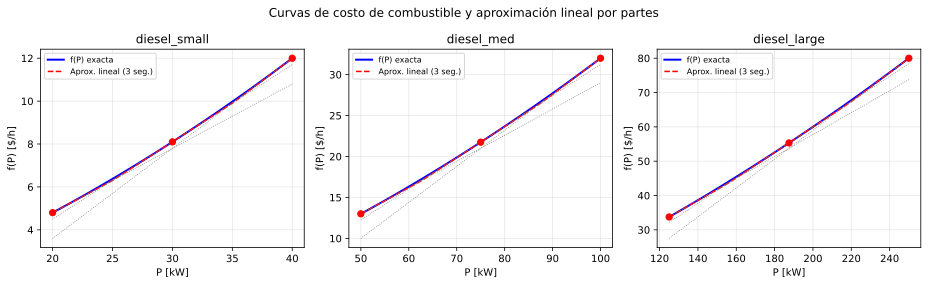


Segmentos lineales de la curva de combustible:
Clase           Seg   P_soporte (kW)   Pendiente S_j   Intercepto s_j
--------------------------------------------------------------------
diesel_small      0             20.0         0.30000          -1.2000
diesel_small      1             30.0         0.36000          -2.7000
diesel_small      2             40.0         0.42000          -4.8000

diesel_med        0             50.0         0.32000          -3.0000
diesel_med        1             75.0         0.38000          -6.7500
diesel_med        2            100.0         0.44000         -12.0000

diesel_large      0            125.0         0.32000          -6.2500
diesel_large      1            187.5         0.37000         -14.0625
diesel_large      2            250.0         0.42000         -25.0000



In [57]:
# ── Coeficientes de la curva cuadrática de combustible por clase ─────────────
# f(P) = a·P² + b·P  [$/h],  P en kW
quad_params = {
    'diesel_small': {'a': 0.003,   'b': 0.18},
    'diesel_med':   {'a': 0.0012,  'b': 0.20},
    'diesel_large': {'a': 0.0004,  'b': 0.22},
}

N_SEG = 3

lin_segments = {}
for g in GENERATORS:
    a  = quad_params[g]['a']
    b  = quad_params[g]['b']
    support_points = np.linspace(min_output[g], max_output[g], N_SEG)
    slopes     = [2 * a * pj + b for pj in support_points]
    intercepts = [-a * pj**2      for pj in support_points]
    lin_segments[g] = {'slopes': slopes, 'intercepts': intercepts, 'support': support_points}

SEGMENTS = list(range(N_SEG))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Curvas de costo de combustible y aproximación lineal por partes", fontsize=12)

for ax, g in zip(axes, GENERATORS):
    a = quad_params[g]['a']; b = quad_params[g]['b']
    P = np.linspace(min_output[g], max_output[g], 200)
    f_exact  = a * P**2 + b * P
    f_approx = np.max(np.array([lin_segments[g]['slopes'][j]*P + lin_segments[g]['intercepts'][j]
                                 for j in SEGMENTS]), axis=0)
    ax.plot(P, f_exact,  'b-',  lw=2,   label='f(P) exacta')
    ax.plot(P, f_approx, 'r--', lw=1.5, label='Aprox. lineal (3 seg.)')
    for j in SEGMENTS:
        ax.plot(P, lin_segments[g]['slopes'][j]*P + lin_segments[g]['intercepts'][j],
                'gray', lw=0.8, ls=':')
    ax.scatter(lin_segments[g]['support'],
               [a*pj**2+b*pj for pj in lin_segments[g]['support']],
               color='red', zorder=5, s=40)
    ax.set_xlabel("P [kW]"); ax.set_ylabel("f(P) [$/h]")
    ax.set_title(g); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\nSegmentos lineales de la curva de combustible:")
print(f"{'Clase':<14} {'Seg':>4} {'P_soporte (kW)':>16} {'Pendiente S_j':>15} {'Intercepto s_j':>16}")
print("-" * 68)
for g in GENERATORS:
    for j in SEGMENTS:
        print(f"{g:<14} {j:>4} {lin_segments[g]['support'][j]:>16.1f} {lin_segments[g]['slopes'][j]:>15.5f} {lin_segments[g]['intercepts'][j]:>16.4f}")
    print()

## Perfil de Generación Fotovoltaica

Visualización del perfil horario calculado con el modelo Loyarte, junto con los datos de entrada (irradiancia y temperatura de celda).

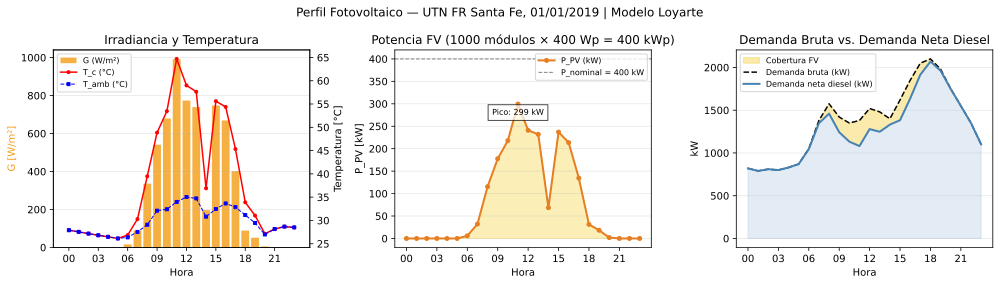

Energía FV total     : 2026.5 kWh/día
Energía demanda total: 32825 kWh/día
Fracción FV          : 6.2%
Reducción pico diesel: 31.3 kW → demanda neta máx = 2069 kW


In [58]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Perfil Fotovoltaico — UTN FR Santa Fe, 01/01/2019 | Modelo Loyarte", fontsize=12)

hours_x = list(range(24))
irrad_vals = [solar_data_df.loc[h,'irradiancia'] for h in hours_x]
temp_vals  = [solar_data_df.loc[h,'temperatura'] for h in hours_x]
tc_vals    = [solar_data_df.loc[h,'temperatura'] + 0.031*solar_data_df.loc[h,'irradiancia'] for h in hours_x]
pv_vals    = [pv_profile[h] for h in hours_x]
demand_bruta = [expected_demand[h] for h in hours_x]
demand_neta  = [net_demand[h] for h in hours_x]

# Irradiancia y temperatura de celda
ax1 = axes[0]
ax1.bar(hours_x, irrad_vals, color='#f39c12', alpha=0.8, label='G (W/m²)', width=0.8)
ax1.set_xlabel('Hora'); ax1.set_ylabel('G [W/m²]', color='#f39c12')
ax1b = ax1.twinx()
ax1b.plot(hours_x, tc_vals, 'r-o', ms=3, lw=1.5, label='T_c (°C)')
ax1b.plot(hours_x, temp_vals, 'b--s', ms=3, lw=1, label='T_amb (°C)')
ax1b.set_ylabel('Temperatura [°C]')
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, lbl1+lbl2, fontsize=8, loc='upper left')
ax1.set_title('Irradiancia y Temperatura')
ax1.set_xticks(range(0,24,3)); ax1.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax1.grid(alpha=0.3, axis='y')

# Potencia PV
ax2 = axes[1]
ax2.fill_between(hours_x, pv_vals, alpha=0.3, color='#f1c40f')
ax2.plot(hours_x, pv_vals, 'o-', color='#e67e22', lw=2, ms=4, label='P_PV (kW)')
ax2.axhline(PV_N*PV_Ppico/1000, color='gray', lw=1, ls='--',
            label=f'P_nominal = {PV_N*PV_Ppico/1000:.0f} kW')
ax2.set_xlabel('Hora'); ax2.set_ylabel('P_PV [kW]')
ax2.set_title(f'Potencia FV ({PV_N} módulos × {PV_Ppico} Wp = {PV_N*PV_Ppico/1000:.0f} kWp)')
ax2.set_xticks(range(0,24,3)); ax2.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, axis='y')
ax2.text(11, max(pv_vals)*0.92, f'Pico: {max(pv_vals):.0f} kW', ha='center', fontsize=8,
         bbox=dict(facecolor='white', alpha=0.7))

# Demanda bruta vs neta
ax3 = axes[2]
ax3.fill_between(hours_x, demand_bruta, demand_neta, alpha=0.35, color='#f1c40f', label='Cobertura FV')
ax3.fill_between(hours_x, demand_neta, alpha=0.15, color='steelblue')
ax3.plot(hours_x, demand_bruta, 'k--', lw=1.5, label='Demanda bruta (kW)')
ax3.plot(hours_x, demand_neta,  'steelblue', lw=2, label='Demanda neta diesel (kW)')
ax3.set_xlabel('Hora'); ax3.set_ylabel('kW')
ax3.set_title('Demanda Bruta vs. Demanda Neta Diesel')
ax3.set_xticks(range(0,24,3)); ax3.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax3.legend(fontsize=8); ax3.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

total_pv_energy  = sum(pv_vals)
total_bruta_energy = sum(demand_bruta)
print(f"Energía FV total     : {total_pv_energy:.1f} kWh/día")
print(f"Energía demanda total: {total_bruta_energy:.0f} kWh/día")
print(f"Fracción FV          : {100*total_pv_energy/total_bruta_energy:.1f}%")
print(f"Reducción pico diesel: {max(demand_bruta)-max(demand_neta):.1f} kW → demanda neta máx = {max(demand_neta):.0f} kW")

## Conexión a la Red Eléctrica (Grid Exchange)

Se agrega la posibilidad de **comprar** y **vender** energía de la red de servicio a través del PCC.

- **Límite del transformador (PCC)**: 500 kW (importación y exportación)
- **Precios de mercado** ($/kWh) – perfil realista para La Rioja / Argentina:

| Período              | Horas     | Precio compra | Precio venta |
|----------------------|-----------|---------------|--------------|
| Valle nocturno       | 00–06     | 0.08          | 0.04         |
| Pico mañana          | 07–11     | 0.22          | 0.06         |
| Media tarde          | 12–17     | 0.15          | 0.05         |
| Pico tarde           | 18–22     | 0.28          | 0.06         |
| Bajada nocturna      | 23        | 0.10          | 0.04         |

**Notas importantes**:
- La reserva operativa (15 %) **sigue calculándose solo sobre generadores diesel** (preparación para modo isla).
- El balance físico ahora es:  
  `∑ diesel + P_PV + p_buy – p_sell = D_bruta`
- Se usa una variable binaria + Big-M para evitar compra y venta simultánea.

In [59]:
# ── Parámetros de conexión a la red ─────────────────────────────
pcc_limit = 500.0  # kW capacidad del PCC

# Precios horarios ($/kWh)
price_buy = {}
price_sell = {}
for h in range(24):
    if 0 <= h <= 6:          # 00–06
        price_buy[h] = 0.08
        price_sell[h] = 0.04
    elif 7 <= h <= 11:       # 07–11
        price_buy[h] = 0.22
        price_sell[h] = 0.06
    elif 12 <= h <= 17:      # 12–17
        price_buy[h] = 0.15
        price_sell[h] = 0.05
    elif 18 <= h <= 22:      # 18–22
        price_buy[h] = 0.28
        price_sell[h] = 0.06
    else:                    # 23
        price_buy[h] = 0.10
        price_sell[h] = 0.04

print("✅ Parámetros de red cargados (PCC = 500 kW)")
print(f"   Precio compra promedio: {sum(price_buy.values())/24:.3f} $/kWh")
print(f"   Precio venta promedio : {sum(price_sell.values())/24:.3f} $/kWh")

✅ Parámetros de red cargados (PCC = 500 kW)
   Precio compra promedio: 0.169 $/kWh
   Precio venta promedio : 0.051 $/kWh


## Construcción del Modelo Pyomo

In [60]:
model = pe.ConcreteModel(name="UC_Microgrid_Diesel_PV")

## Conjuntos del Modelo

In [61]:
model.G = pe.Set(initialize=GENERATORS, doc="Clases de generadores diesel")
model.T = pe.Set(initialize=T, ordered=True, doc="Períodos de tiempo (índices enteros)")
model.J = pe.Set(initialize=SEGMENTS, doc="Segmentos de linealización de costo combustible")

## Parámetros del Modelo

In [62]:
model.num_available           = pe.Param(model.G, initialize=num_available,           doc='Unidades disponibles')
model.min_output              = pe.Param(model.G, initialize=min_output,              doc='Producción mínima [kW]')
model.max_output              = pe.Param(model.G, initialize=max_output,              doc='Producción máxima [kW]')
model.cost_per_hour           = pe.Param(model.G, initialize=cost_per_hour,           doc='Costo fijo O&M [$/h]')
model.startup_cost            = pe.Param(model.G, initialize=startup_cost,            doc='Costo de arranque [$]')
model.shutdown_cost           = pe.Param(model.G, initialize=shutdown_cost,           doc='Costo de apagado [$]')
model.min_up_time             = pe.Param(model.G, initialize=min_up_time,             doc='Tiempo mínimo encendido [períodos]')
model.min_down_time           = pe.Param(model.G, initialize=min_down_time,           doc='Tiempo mínimo apagado [períodos]')
model.ramp_limit              = pe.Param(model.G, initialize=ramp_limit,              doc='Límite de rampa [kW/h]')
model.state0                  = pe.Param(model.G, initialize=state0,                  doc='Estado inicial')
model.expected_demand         = pe.Param(model.T, initialize=expected_demand,         doc='Demanda bruta [kW]')
model.pv_output               = pe.Param(model.T, initialize=pv_output,               doc='Generación FV (Loyarte) [kW]')
model.net_demand              = pe.Param(model.T, initialize=net_demand,               doc='Demanda neta diesel = D - P_PV [kW]')
model.minimum_active_capacity = pe.Param(model.T, initialize=minimum_active_capacity, doc='Capacidad activa mínima = 1.15 × D_neta [kW]')

slope_data     = {(g, j): lin_segments[g]['slopes'][j]     for g in GENERATORS for j in SEGMENTS}
intercept_data = {(g, j): lin_segments[g]['intercepts'][j] for g in GENERATORS for j in SEGMENTS}

model.lin_slope     = pe.Param(model.G, model.J, initialize=slope_data,     doc='Pendiente S_j')
model.lin_intercept = pe.Param(model.G, model.J, initialize=intercept_data, doc='Intercepto s_j')

### Conexión a la Red Principal (PCC)

Se modela el intercambio de energía con la red mediante:

* $P^{\mathrm{buy}}_t$: potencia comprada desde la red [kW]
* $P^{\mathrm{sell}}_t$: potencia vendida hacia la red [kW]
* $u^{\mathrm{buy}}_t \in \{0,1\}$: variable binaria que define el modo de operación

#### Balance de energía (demanda bruta)

$$\sum_{g \in G} P_{g,t} + P^{PV}_t + P^{\mathrm{buy}}_t - P^{\mathrm{sell}}_t = D_t$$

#### Restricciones del PCC (Big-M)

$$P^{\mathrm{buy}}_t \leq P^{PCC}_{max} \cdot u^{\mathrm{buy}}_t$$

$$P^{\mathrm{sell}}_t \leq P^{PCC}_{max} \cdot (1 - u^{\mathrm{buy}}_t)$$

Estas ecuaciones aseguran:

* Límite físico del transformador
* No simultaneidad de compra y venta

#### Función objetivo (extensión)

$$\min \quad C_{\text{diesel}} + \sum_t \left( \pi^{\mathrm{buy}}_t P^{\mathrm{buy}}_t - \pi^{\mathrm{sell}}_t P^{\mathrm{sell}}_t \right)$$


In [63]:
# Límite del PCC (kW)
model.pcc_limit = pe.Param(initialize=500)

# Precios horarios
price_buy_dict = {}
price_sell_dict = {}

for t in model.T:
    if 0 <= t <= 6:
        price_buy_dict[t] = 0.08
        price_sell_dict[t] = 0.04
    elif 7 <= t <= 11:
        price_buy_dict[t] = 0.22
        price_sell_dict[t] = 0.06
    elif 12 <= t <= 17:
        price_buy_dict[t] = 0.15
        price_sell_dict[t] = 0.05
    elif 18 <= t <= 22:
        price_buy_dict[t] = 0.28
        price_sell_dict[t] = 0.06
    else:  # t == 23
        price_buy_dict[t] = 0.10
        price_sell_dict[t] = 0.04

model.price_buy = pe.Param(model.T, initialize=price_buy_dict)
model.price_sell = pe.Param(model.T, initialize=price_sell_dict)

## Resumen de Variables de Decisión

La incorporación del GFV no agrega nuevas variables de decisión al modelo: la generación fotovoltaica $P^{\mathrm{PV}}_t$ es un parámetro determinístico calculado en pre-proceso. El modelo decide únicamente cuántos generadores diesel activar y cuánta energía producir para cubrir la demanda neta.

### Variables Continuas

| Variable | Índices | Dominio | Unidad | Descripción |
| :--- | :---: | :---: | :---: | :--- |
| $x_{g,t}$ (`output`) | $g \in G,\; t \in T$ | $\mathbb{R}_{\geq 0}$ | kW | Producción total de la clase $g$ en el período $t$ |
| $\sigma_{g,t}$ (`sigma`) | $g \in G,\; t \in T$ | $\mathbb{R}_{\geq 0}$ | $/h | Costo de combustible — variable de linealización Parisio |

### Variables Enteras

| Variable | Índices | Dominio | Unidad | Descripción |
| :--- | :---: | :---: | :---: | :--- |
| $n_{g,t}$ (`num_active`) | $g \in G,\; t \in T$ | $\{0,\ldots,n_g\}$ | unidades | Generadores activos |
| $u_{g,t}$ (`num_startup`) | $g \in G,\; t \in T$ | $\mathbb{Z}_{\geq 0}$ | unidades | Arranques en $t$ |
| $v_{g,t}$ (`num_shutdown`) | $g \in G,\; t \in T$ | $\mathbb{Z}_{\geq 0}$ | unidades | Apagados en $t$ |

### Dimensiones del Modelo

| Tipo                                 | Cantidad |
| :----------------------------------- | :------: |
| Clases de generadores ($\|G\|$)      | 3        |
| Períodos de tiempo ($\|T\|$)         | 24       |
| Segmentos de linealización ($\|J\|$) | 3        |
| Variables continuas                  | 144      |
| Variables enteras                    | 216      |
| Total variables                      | 360      |

### Variables de intercambio con la red

Se incorporan variables continuas para los flujos y una binaria para evitar simultaneidad:

* $ P^{\text{buy}}_t \geq 0 $
* $ P^{\text{sell}}_t \geq 0 $
* $ u^{\text{buy}}_t \in \{0,1\} $

## Definición de Variables

In [ ]:
model.output = pe.Var(model.G, model.T, within=pe.NonNegativeReals, doc="Producción total [kW]")

model.sigma  = pe.Var(model.G, model.T, within=pe.NonNegativeReals,
                      doc="Costo combustible [$/h] — linealización Parisio")

def num_active_bounds(m, g, t): return (0, m.num_available[g])
model.num_active   = pe.Var(model.G, model.T, within=pe.NonNegativeIntegers,
                             bounds=num_active_bounds, doc="Generadores activos")
model.num_startup  = pe.Var(model.G, model.T, within=pe.NonNegativeIntegers, doc="Arranques")
model.num_shutdown = pe.Var(model.G, model.T, within=pe.NonNegativeIntegers, doc="Apagados")

# Variables de intercambio con la red
model.p_buy     = pe.Var(model.T, within=pe.NonNegativeReals, doc="Potencia comprada de red [kW]")
model.p_sell    = pe.Var(model.T, within=pe.NonNegativeReals, doc="Potencia vendida a red [kW]")
model.is_buying = pe.Var(model.T, within=pe.Binary, doc="1=comprando, 0=vendiendo (Big-M)")

## Restricciones

### 1. Satisfacción de la Demanda Neta

Los generadores diesel deben cubrir exactamente la demanda neta (demanda bruta menos generación fotovoltaica):

$$\sum_{g \in G} x_{g,t} + P^{\mathrm{PV}}_t + P^{\mathrm{buy}}_t - P^{\mathrm{sell}}_t = D_t  \qquad \forall t \in T$$

In [65]:
def demand_rule(m, t):
    # Balance físico completo
    return (sum(m.output[g, t] for g in m.G) +
            m.p_buy[t] - m.p_sell[t] ==
            m.expected_demand[t] - m.pv_output[t])   # = D_bruta - P_PV

model.demand_constraint = pe.Constraint(
    model.T, rule=demand_rule,
    doc="∑ diesel + p_buy - p_sell = D_bruta - P_PV"
)

### 2. Restricción de Reserva Operativa

La capacidad instalada activa debe cubrir el 15% de reserva sobre la **demanda neta**:

$$\sum_{g \in G} P^{\max}_g \cdot n_{g,t} \geq 1{,}15 \cdot D^{\mathrm{net}}_t \qquad \forall t \in T$$

In [66]:
def reserve_rule(m, t):
    return sum(m.max_output[g] * m.num_active[g, t] for g in m.G) >= m.minimum_active_capacity[t]

model.reserve_constraint = pe.Constraint(
    model.T, rule=reserve_rule,
    doc="Capacidad activa >= 1.15 × demanda neta"
)

### 3. Límites de Producción por Unidad Activa

$$P^{\min}_g \cdot n_{g,t} \leq x_{g,t} \leq P^{\max}_g \cdot n_{g,t} \qquad \forall g \in G, t \in T$$

In [67]:
def output_lower_rule(m, g, t): return m.output[g, t] >= m.min_output[g] * m.num_active[g, t]
model.output_lower = pe.Constraint(model.G, model.T, rule=output_lower_rule, doc="Producción >= mínimo")

def output_upper_rule(m, g, t): return m.output[g, t] <= m.max_output[g] * m.num_active[g, t]
model.output_upper = pe.Constraint(model.G, model.T, rule=output_upper_rule, doc="Producción <= máximo")

### 4. Balance de Estado: Arranques

$$u_{g,t} \geq n_{g,t} - n_{g,t-1} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$
$$u_{g,t_0} \geq n_{g,t_0} - a^0_g \qquad \forall g \in G$$

In [68]:
def startup_rule(m, g, t):
    if t == m.T.first(): return pe.Constraint.Skip
    return m.num_startup[g, t] >= m.num_active[g, t] - m.num_active[g, m.T.prev(t)]

model.startup_constraint = pe.Constraint(model.G, model.T, rule=startup_rule)

def initial_startup_rule(m, g):
    return m.num_startup[g, m.T.first()] >= m.num_active[g, m.T.first()] - m.state0[g]

model.initial_startup = pe.Constraint(model.G, rule=initial_startup_rule)

### 5. Balance de Estado: Apagados

$$v_{g,t} \geq n_{g,t-1} - n_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$
$$v_{g,t_0} \geq a^0_g - n_{g,t_0} \qquad \forall g \in G$$

In [69]:
def shutdown_rule(m, g, t):
    if t == m.T.first(): return pe.Constraint.Skip
    return m.num_shutdown[g, t] >= m.num_active[g, m.T.prev(t)] - m.num_active[g, t]

model.shutdown_constraint = pe.Constraint(model.G, model.T, rule=shutdown_rule)

def initial_shutdown_rule(m, g):
    return m.num_shutdown[g, m.T.first()] >= m.state0[g] - m.num_active[g, m.T.first()]

model.initial_shutdown = pe.Constraint(model.G, rule=initial_shutdown_rule)

### 6. Tiempo Mínimo de Encendido (Min Up-Time)

$$\sum_{k=t-\tau^{\mathrm{up}}_g+1}^{t} u_{g,k} \leq n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{up}}_g$$

In [70]:
def min_up_time_rule(m, g, t):
    mut = int(pe.value(m.min_up_time[g]))
    if mut <= 1: return pe.Constraint.Skip
    t_list = list(m.T)
    if t < mut - 1: return pe.Constraint.Skip
    window = [t_list[k] for k in range(t - mut + 1, t + 1) if k >= 0]
    return sum(m.num_startup[g, tau] for tau in window) <= m.num_active[g, t_list[t]]

model.min_up_time_constraint = pe.Constraint(model.G, model.T, rule=min_up_time_rule)

### 7. Tiempo Mínimo de Apagado (Min Down-Time)

$$\sum_{k=t-\tau^{\mathrm{dn}}_g+1}^{t} v_{g,k} \leq n_g - n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{dn}}_g$$

In [71]:
def min_down_time_rule(m, g, t):
    mdt = int(pe.value(m.min_down_time[g]))
    if mdt <= 1: return pe.Constraint.Skip
    t_list = list(m.T)
    if t < mdt - 1: return pe.Constraint.Skip
    window = [t_list[k] for k in range(t - mdt + 1, t + 1) if k >= 0]
    return sum(m.num_shutdown[g, tau] for tau in window) <= m.num_available[g] - m.num_active[g, t_list[t]]

model.min_down_time_constraint = pe.Constraint(model.G, model.T, rule=min_down_time_rule)

### 8. Linealización de la Curva de Combustible (Enfoque Parisio)

$$\sigma_{g,t} \geq S_j^g \cdot x_{g,t} + s_j^g \cdot n_{g,t} \qquad \forall g \in G,\; t \in T,\; j \in J$$

In [72]:
def fuel_cost_linearization_rule(m, g, t, j):
    return m.sigma[g, t] >= m.lin_slope[g, j] * m.output[g, t] + m.lin_intercept[g, j] * m.num_active[g, t]

model.fuel_cost_linearization = pe.Constraint(
    model.G, model.T, model.J, rule=fuel_cost_linearization_rule,
    doc="Linealización Parisio"
)

### 9. Restricciones de Rampa (Ramp-Up y Ramp-Down)

Formuladas con $R_g = P^{\max}_g$ (trivialmente satisfechas dado que el diesel cicla en minutos):

**Rampa de subida:**
$$x_{g,t} - x_{g,t-1} \leq R_g \cdot n_{g,t-1} + P^{\max}_g \cdot u_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Rampa de bajada:**
$$x_{g,t-1} - x_{g,t} \leq R_g \cdot n_{g,t} + P^{\max}_g \cdot v_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

In [73]:
def ramp_up_rule(m, g, t):
    if t == m.T.first(): return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    return (m.output[g, t] - m.output[g, t_prev]
            <= m.ramp_limit[g] * m.num_active[g, t_prev]
               + m.max_output[g] * m.num_startup[g, t])

model.ramp_up_constraint = pe.Constraint(model.G, model.T, rule=ramp_up_rule, doc='Rampa subida')

def ramp_down_rule(m, g, t):
    if t == m.T.first(): return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    return (m.output[g, t_prev] - m.output[g, t]
            <= m.ramp_limit[g] * m.num_active[g, t]
               + m.max_output[g] * m.num_shutdown[g, t])

model.ramp_down_constraint = pe.Constraint(model.G, model.T, rule=ramp_down_rule, doc='Rampa bajada')

print('Restricciones de rampa (triviales):')
for g in GENERATORS:
    print(f'  {g:<14}  ramp_limit = {ramp_limit[g]:>5} kW/h = Pmax → siempre satisfecha')

Restricciones de rampa (triviales):
  diesel_small    ramp_limit =  40.0 kW/h = Pmax → siempre satisfecha
  diesel_med      ramp_limit = 100.0 kW/h = Pmax → siempre satisfecha
  diesel_large    ramp_limit = 250.0 kW/h = Pmax → siempre satisfecha


## Función Objetivo

El GFV no tiene costo variable (combustible = 0, O&M ≈ 0 en el horizonte diario). Solo se minimizan los costos de los generadores diesel:

$$\min \sum_{g \in G} \sum_{t \in T} \left[
  \underbrace{c_g \cdot n_{g,t}}_{\text{O\&M fijo}}
  + \underbrace{\sigma_{g,t}}_{\text{combustible (Parisio)}}
  + \underbrace{s^u_g \cdot u_{g,t}}_{\text{arranque}}
  + \underbrace{s^d_g \cdot v_{g,t}}_{\text{apagado}}
\right]$$

In [74]:
def obj_rule(m):
    return sum(
        m.cost_per_hour[g]  * m.num_active[g, t]
        + m.sigma[g, t]
        + m.startup_cost[g]  * m.num_startup[g, t]
        + m.shutdown_cost[g] * m.num_shutdown[g, t]
        for g in m.G for t in m.T
    )

model.obj = pe.Objective(rule=obj_rule, sense=pe.minimize,
                          doc="Minimizar costo total de operación diesel")

In [75]:
nG, nT, nJ = len(GENERATORS), len(T), N_SEG

print("=" * 65)
print("  RESUMEN DEL MODELO UC — MICRORRED DIESEL + FV  V5")
print("=" * 65)

print("\n── Conjuntos ─────────────────────────────────────────────")
print(f"  |G| Clases de generadores          : {nG}")
print(f"  |T| Períodos de tiempo             : {nT}")
print(f"  |J| Segmentos de linealización     : {nJ}")

print("\n── Variables continuas ───────────────────────────────────")
print(f"  output  (x_{{g,t}})                  : {nG*nT:>4}  [kW]")
print(f"  sigma   (σ_{{g,t}})                  : {nG*nT:>4}  [$/h]")
print(f"  Subtotal continuas                 : {2*nG*nT:>4}")

print("\n── Variables enteras ─────────────────────────────────────")
print(f"  num_active   (n_{{g,t}})  ∈ [0, n_g] : {nG*nT:>4}  [unidades]")
print(f"  num_startup  (u_{{g,t}})  ≥ 0        : {nG*nT:>4}  [unidades]")
print(f"  num_shutdown (v_{{g,t}})  ≥ 0        : {nG*nT:>4}  [unidades]")
print(f"  Subtotal enteras                   : {3*nG*nT:>4}")
print(f"\n  TOTAL VARIABLES                    : {5*nG*nT:>4}")

print("\n── Restricciones ─────────────────────────────────────────")
print(f"  Demanda neta (D - P_PV)            : {nT:>4}")
print(f"  Reserva operativa (1.15 × D_neta)  : {nT:>4}")
print(f"  Límites producción (inf + sup)     : {2*nG*nT:>4}")
print(f"  Arranque (t>t0 + inicial)          : {nG*(nT-1)+nG:>4}")
print(f"  Apagado  (t>t0 + inicial)          : {nG*(nT-1)+nG:>4}")
print(f"  Min up time                        : {nG*nT:>4}  (activa si MUT>1)")
print(f"  Min down time                      : {nG*nT:>4}  (activa si MDT>1)")
print(f"  Linealización combustible          : {nG*nT*nJ:>4}")
print(f"  Rampa de subida (trivial)          : {nG*(nT-1):>4}")
print(f"  Rampa de bajada (trivial)          : {nG*(nT-1):>4}")
total_r = 2*nT + 2*nG*nT + 2*(nG*(nT-1)+nG) + 2*nG*nT + nG*nT*nJ + 2*nG*(nT-1)
print(f"  TOTAL RESTRICCIONES                : {total_r:>4}")
print("=" * 65)
print()
print(f"── Generación FV (pre-proceso) ───────────────────────────")
print(f"  Instalación nominal : {PV_N*PV_Ppico/1000:.0f} kWp ({PV_N} módulos × {PV_Ppico} Wp)")
print(f"  Pico horario FV     : {max(pv_profile.values()):.1f} kW (h=11)")
print(f"  Energía FV total    : {sum(pv_profile.values()):.1f} kWh/día")
print(f"  Cobertura           : {100*sum(pv_profile.values())/sum(expected_demand.values()):.1f}% de la demanda bruta")
print("=" * 65)

  RESUMEN DEL MODELO UC — MICRORRED DIESEL + FV  V5

── Conjuntos ─────────────────────────────────────────────
  |G| Clases de generadores          : 3
  |T| Períodos de tiempo             : 24
  |J| Segmentos de linealización     : 3

── Variables continuas ───────────────────────────────────
  output  (x_{g,t})                  :   72  [kW]
  sigma   (σ_{g,t})                  :   72  [$/h]
  Subtotal continuas                 :  144

── Variables enteras ─────────────────────────────────────
  num_active   (n_{g,t})  ∈ [0, n_g] :   72  [unidades]
  num_startup  (u_{g,t})  ≥ 0        :   72  [unidades]
  num_shutdown (v_{g,t})  ≥ 0        :   72  [unidades]
  Subtotal enteras                   :  216

  TOTAL VARIABLES                    :  360

── Restricciones ─────────────────────────────────────────
  Demanda neta (D - P_PV)            :   24
  Reserva operativa (1.15 × D_neta)  :   24
  Límites producción (inf + sup)     :  144
  Arranque (t>t0 + inicial)          :   72
  Apag

## Resolución del Modelo

Configuración del solver MILP. Ver [parámetros de GUROBI](https://docs.gurobi.com/projects/optimizer/en/current/concepts/parameters.html).

In [76]:
solver = pe.SolverFactory('gurobi_direct')
solver.options['MIPGap']    = 0
solver.options['MIPFocus']  = 1
solver.options['OutputFlag']= 1

t0 = time.time()
results = solver.solve(model, tee=True)
cpu_time = time.time() - t0

print(f"\nTiempo de CPU: {cpu_time:.2f} s")

Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
Set parameter MIPFocus to value 1
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7430U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
MIPGap  0
MIPFocus  1

Academic license 2723234 - for non-commercial use only - registered to nz___@frsf.utn.edu.ar
Optimize a model with 690 rows, 432 columns and 2106 nonzeros (Min)
Model fingerprint: 0x2392067f
Model has 288 linear objective coefficients
Variable types: 192 continuous, 240 integer (24 binary)
Coefficient statistics:
  Matrix range     [3e-01, 3e+02]
  Objective range  [1e+00, 3e+01]
  Bounds range     [1e+00, 1e+01]
  RHS range        [8e+02, 2e+03]
Found heuristic solution: objective 8593.0500000
Presolve removed 91 rows and 94 columns
Presolve time: 0.00s
Presolve

## Verificación de la Solución

In [77]:
tc = results.solver.termination_condition

if tc == pe.TerminationCondition.optimal:
    print("Solución ÓPTIMA encontrada")
elif tc == pe.TerminationCondition.feasible:
    print("Solución FACTIBLE encontrada (límite de tiempo alcanzado)")
elif tc == pe.TerminationCondition.infeasible:
    print("Problema INFACTIBLE")
else:
    print(f"Estado del solver: {tc}")

costo_total = pe.value(model.obj)
print(f"\nCosto total óptimo : ${costo_total:,.2f}")
print(f"Tiempo de CPU      : {cpu_time:.2f} s")

Solución ÓPTIMA encontrada

Costo total óptimo : $7,155.30
Tiempo de CPU      : 1.05 s


## Extracción de Resultados

In [78]:
rows = []
for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        nd  = int(round(pe.value(model.num_shutdown[g, i])))
        out = pe.value(model.output[g, i])
        sig = pe.value(model.sigma[g, i])
        c_fixed    = generator_data.loc[g, 'cost_per_hour'] * na
        c_fuel     = sig
        c_startup  = generator_data.loc[g, 'startup_cost']  * ns
        c_shutdown = generator_data.loc[g, 'shutdown_cost'] * nd
        c_total    = c_fixed + c_fuel + c_startup + c_shutdown
        rows.append({
            'generator_class': g, 'time_period': t,
            'output (kW)': round(out, 1), 'num_active': na,
            'num_startup': ns, 'num_shutdown': nd,
            'sigma ($/h)': round(sig, 2),
            'cost_fixed ($)': round(c_fixed, 2),
            'cost_fuel ($)': round(c_fuel, 2),
            'cost_startup ($)': round(c_startup, 2),
            'cost_shutdown ($)': round(c_shutdown, 2),
            'cost_total ($)': round(c_total, 2),
        })

solution = pd.DataFrame(rows).set_index(['generator_class', 'time_period'])

active_capacity = {
    t: sum(int(round(pe.value(model.num_active[g, i]))) * generator_data.loc[g, 'max_output']
           for g in GENERATORS)
    for i, t in enumerate(TIME_PERIODS)
}

results_summary = pd.DataFrame({
    'Demanda bruta (kW)':       time_period_data['expected_demand'],
    'P_PV (kW)':                pd.Series({t: pv_profile[i] for i, t in enumerate(TIME_PERIODS)}),
    'Demanda neta (kW)':        pd.Series({t: net_demand[i] for i, t in enumerate(TIME_PERIODS)}),
    'Cap. Min. Activa (kW)':    pd.Series({t: minimum_active_capacity[i] for i, t in enumerate(TIME_PERIODS)}),
    'Cap. Activa Real (kW)':    pd.Series(active_capacity),
})

print("Resumen por período:")
print(results_summary)

Resumen por período:
                     Demanda bruta (kW)  P_PV (kW)  Demanda neta (kW)  \
2024-01-01 00:00:00                 820       0.00             820.00   
2024-01-01 01:00:00                 790       0.00             790.00   
2024-01-01 02:00:00                 810       0.00             810.00   
2024-01-01 03:00:00                 800       0.00             800.00   
2024-01-01 04:00:00                 830       0.00             830.00   
2024-01-01 05:00:00                 870       0.00             870.00   
2024-01-01 06:00:00                1050       5.84            1044.16   
2024-01-01 07:00:00                1380      32.03            1347.97   
2024-01-01 08:00:00                1575     115.47            1459.53   
2024-01-01 09:00:00                1420     177.65            1242.35   
2024-01-01 10:00:00                1350     217.98            1132.02   
2024-01-01 11:00:00                1380     299.45            1080.55   
2024-01-01 12:00:00           

## Tabla de Resultados Detallada

In [79]:
sep = "=" * 100
print(sep)
print(f"{'Generador':<14} {'Período':<10} {'Act':>5} {'Arr':>5} {'Apr':>5} "
      f"{'Prod.(kW)':>10} {'σ(/h)':>8} {'C.Fixed':>8} {'C.Fuel':>8} {'C.Start':>8} {'C.Stop':>8} {'C.Total':>9}")
print(sep)

for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        nd  = int(round(pe.value(model.num_shutdown[g, i])))
        out = pe.value(model.output[g, i])
        sig = pe.value(model.sigma[g, i])
        cf  = generator_data.loc[g, 'cost_per_hour']  * na
        cs  = generator_data.loc[g, 'startup_cost']   * ns
        cd  = generator_data.loc[g, 'shutdown_cost']  * nd
        ct  = cf + sig + cs + cd
        print(f"{g:<14} {str(t.time()):<10} {na:>5d} {ns:>5d} {nd:>5d} "
              f"{out:>10.1f} {sig:>8.2f} {cf:>8.2f} {sig:>8.2f} {cs:>8.2f} {cd:>8.2f} {ct:>9.2f}")
    print("-" * 100)

print(sep)
print(f"\nCosto total óptimo: ${costo_total:,.2f}")

c_om_total   = sum(generator_data.loc[g,'cost_per_hour']*int(round(pe.value(model.num_active[g,i])))
                   for g in GENERATORS for i in T)
c_fuel_total = sum(pe.value(model.sigma[g,i]) for g in GENERATORS for i in T)
c_start_total= sum(generator_data.loc[g,'startup_cost']*int(round(pe.value(model.num_startup[g,i])))
                   for g in GENERATORS for i in T)
c_stop_total = sum(generator_data.loc[g,'shutdown_cost']*int(round(pe.value(model.num_shutdown[g,i])))
                   for g in GENERATORS for i in T)

print(f"\n Descomposición del costo diesel:")
print(f"   O&M fijo    : {c_om_total:>8.2f}  ({100*c_om_total/costo_total:.1f}%)")
print(f"   Combustible : {c_fuel_total:>8.2f}  ({100*c_fuel_total/costo_total:.1f}%)")
print(f"   Arranque    : {c_start_total:>8.2f}  ({100*c_start_total/costo_total:.1f}%)")
print(f"   Apagado     : {c_stop_total:>8.2f}  ({100*c_stop_total/costo_total:.1f}%)")

Generador      Período      Act   Arr   Apr  Prod.(kW)    σ(/h)  C.Fixed   C.Fuel  C.Start   C.Stop   C.Total
diesel_small   00:00:00      10    10     0      200.0    48.00    25.00    48.00    50.00     0.00    123.00
diesel_small   01:00:00      10     0     0      200.0    48.00    25.00    48.00     0.00     0.00     73.00
diesel_small   02:00:00      10     0     0      200.0    48.00    25.00    48.00     0.00     0.00     73.00
diesel_small   03:00:00      10     0     0      200.0    48.00    25.00    48.00     0.00     0.00     73.00
diesel_small   04:00:00      11     1     0      220.0    52.80    27.50    52.80     5.00     0.00     85.30
diesel_small   05:00:00      12     1     0      240.0    57.60    30.00    57.60     5.00     0.00     92.60
diesel_small   06:00:00      12     0     0      240.0    57.60    30.00    57.60     0.00     0.00     87.60
diesel_small   07:00:00      12     0     0      240.0    57.60    30.00    57.60     0.00     0.00     87.60
diesel_sma

## Análisis Gráfico

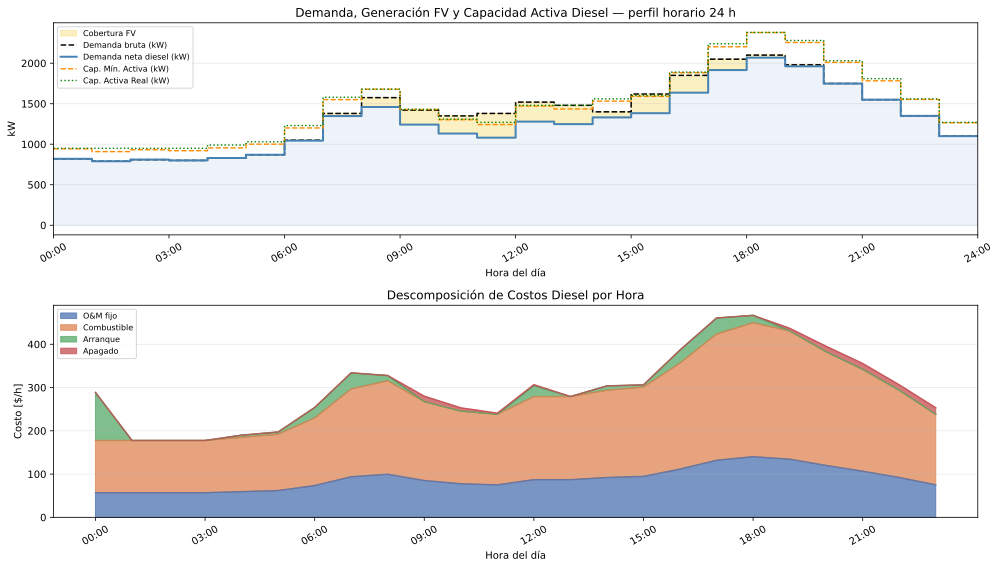

In [80]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']
sns.set_palette(sns.color_palette("deep"))

hours       = list(range(24))
demand_bruta_vals = list(time_period_data['expected_demand'])
pv_vals     = [pv_profile[i] for i in T]
demand_neta_vals  = [net_demand[i] for i in T]
min_cap_vals= [minimum_active_capacity[i] for i in T]
act_cap_vals= list(results_summary['Cap. Activa Real (kW)'])

def make_step(values):
    xs, ys = [], []
    for h, v in enumerate(values):
        xs += [h, h + 1]; ys += [v, v]
    return xs, ys

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Gráfico 1: Demanda bruta, neta, FV y capacidad activa ─────────────────────
ax1 = axes[0]
xs_db, ys_db = make_step(demand_bruta_vals)
xs_dn, ys_dn = make_step(demand_neta_vals)
xs_pv, ys_pv = make_step(pv_vals)
xs_mc, ys_mc = make_step(min_cap_vals)
xs_ac, ys_ac = make_step(act_cap_vals)

ax1.fill_between(xs_db, ys_db, ys_dn, alpha=0.25, color='#f1c40f', step=None, label='Cobertura FV')
ax1.fill_between(xs_dn, ys_dn, alpha=0.10, color='steelblue', step=None)
ax1.plot(xs_db, ys_db, 'k--',        lw=1.5,       label='Demanda bruta (kW)')
ax1.plot(xs_dn, ys_dn, 'steelblue',  lw=2,         label='Demanda neta diesel (kW)')
ax1.plot(xs_mc, ys_mc, 'darkorange', lw=1.4, ls='--', label='Cap. Mín. Activa (kW)')
ax1.plot(xs_ac, ys_ac, 'green',      lw=1.4, ls=':',  label='Cap. Activa Real (kW)')

ax1.set_xlabel("Hora del día"); ax1.set_ylabel("kW")
ax1.set_title("Demanda, Generación FV y Capacidad Activa Diesel — perfil horario 24 h")
ax1.set_xlim(0, 24); ax1.set_xticks(range(0, 25, 3))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 3)], rotation=30)
ax1.legend(loc='upper left', fontsize=8); ax1.grid(alpha=0.3, axis='y')

# ── Gráfico 2: Descomposición de costos por hora ──────────────────────────────
ax2 = axes[1]
period_costs = pd.DataFrame(index=hours)
for component, label in [
    ('cost_fixed ($)', 'O&M fijo'), ('cost_fuel ($)', 'Combustible'),
    ('cost_startup ($)', 'Arranque'), ('cost_shutdown ($)', 'Apagado'),
]:
    period_costs[label] = solution.groupby('time_period')[component].sum().values

period_costs.plot.area(ax=ax2, alpha=0.75)
ax2.set_xlabel("Hora del día"); ax2.set_ylabel("Costo [$/h]")
ax2.set_title("Descomposición de Costos Diesel por Hora")
ax2.set_xticks(range(0, 24, 3))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=30)
ax2.legend(fontsize=8, loc='upper left'); ax2.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

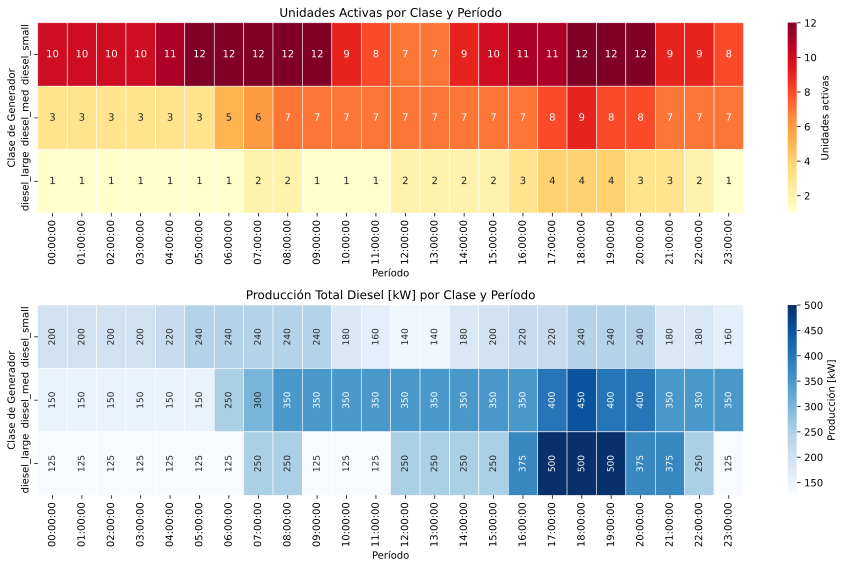

In [81]:
active_matrix = pd.DataFrame(
    index=GENERATORS,
    columns=[str(t.time()) for t in TIME_PERIODS],
    data=[[int(round(pe.value(model.num_active[g, i]))) for i in T] for g in GENERATORS]
)

output_matrix = pd.DataFrame(
    index=GENERATORS,
    columns=[str(t.time()) for t in TIME_PERIODS],
    data=[[round(pe.value(model.output[g, i]), 1) for i in T] for g in GENERATORS]
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

sns.heatmap(active_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Unidades activas'}, ax=axes[0])
axes[0].set_title("Unidades Activas por Clase y Período")
axes[0].set_xlabel("Período"); axes[0].set_ylabel("Clase de Generador")

sns.heatmap(output_matrix, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Producción [kW]'},
            annot_kws={"size": 9, "rotation": 90}, ax=axes[1])
axes[1].set_title("Producción Total Diesel [kW] por Clase y Período")
axes[1].set_xlabel("Período"); axes[1].set_ylabel("Clase de Generador")

plt.tight_layout(); plt.show()

### Mix de Generación y Curva de Duración de Carga

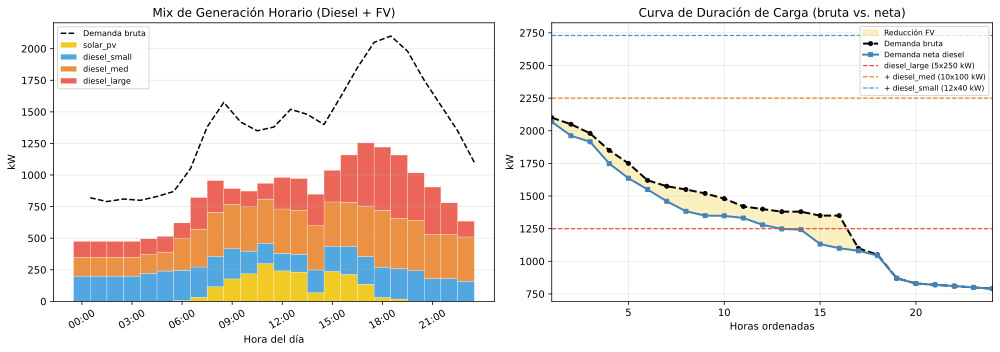

In [82]:
gen_colors = {'diesel_small': '#3498db', 'diesel_med': '#e67e22', 'diesel_large': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Mix de generación horario (área apilada) con FV ───────────────────────────
ax1 = axes[0]
bottoms = np.zeros(24)

# FV primero (base de la pila)
ax1.bar(hours, pv_vals, bottom=bottoms, color='#f1c40f',
        alpha=0.9, label='solar_pv', width=1.0, edgecolor='white', linewidth=0.3)
bottoms += np.array(pv_vals)

for g in GENERATORS:
    vals = [pe.value(model.output[g, i]) for i in T]
    ax1.bar(hours, vals, bottom=bottoms, color=gen_colors[g],
            alpha=0.85, label=g, width=1.0, edgecolor='white', linewidth=0.3)
    bottoms += np.array(vals)

ax1.plot([h + 0.5 for h in hours], demand_bruta_vals, 'k--', lw=1.5, label='Demanda bruta', zorder=5)
ax1.set_xlabel("Hora del día"); ax1.set_ylabel("kW")
ax1.set_title("Mix de Generación Horario (Diesel + FV)")
ax1.set_xticks(range(0, 24, 3)); ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=30)
ax1.legend(fontsize=8); ax1.grid(alpha=0.3, axis='y')

# ── Curva de duración de carga (con y sin FV) ─────────────────────────────────
ax2 = axes[1]
sorted_bruta = sorted(demand_bruta_vals, reverse=True)
sorted_neta  = sorted(demand_neta_vals,  reverse=True)
ax2.fill_between(range(1, 25), sorted_bruta, sorted_neta, alpha=0.25, color='#f1c40f', label='Reducción FV')
ax2.plot(range(1, 25), sorted_bruta, 'k--',       lw=2, marker='o', ms=4, label='Demanda bruta')
ax2.plot(range(1, 25), sorted_neta,  'steelblue', lw=2, marker='s', ms=4, label='Demanda neta diesel')

cap_lines = [
    (5*250,              'diesel_large (5x250 kW)', '#e74c3c'),
    (5*250+10*100,       '+ diesel_med (10x100 kW)', '#e67e22'),
    (5*250+10*100+12*40, '+ diesel_small (12x40 kW)', '#3498db'),
]
for cap, lbl, col in cap_lines:
    ax2.axhline(cap, color=col, lw=1.2, ls='--', label=lbl)

ax2.set_xlabel("Horas ordenadas"); ax2.set_ylabel("kW")
ax2.set_title("Curva de Duración de Carga (bruta vs. neta)")
ax2.set_xlim(1, 24); ax2.legend(fontsize=7.5, loc='upper right'); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

La Curva de Duración de Carga con generación FV muestra cómo la generación solar **desplaza hacia abajo** la curva de demanda neta durante las horas centrales del día. La zona amarilla representa la energía cubierta por el GFV en cada hora ordenada. Al reducirse la demanda neta, el despacho diesel es menor y potencialmente se pueden apagar unidades durante las horas de mayor irradiación solar.

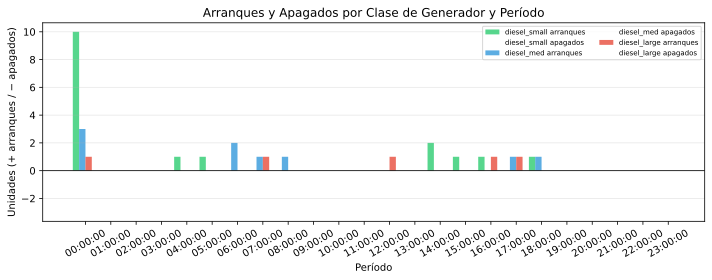

In [83]:
fig, ax = plt.subplots(figsize=(10, 4))
width = 0.25
x = np.arange(len(TIME_PERIODS))
labels = [str(t.time()) for t in TIME_PERIODS]
colors_start = ['#2ecc71', '#3498db', '#e74c3c']
colors_stop  = ['#27ae60', '#2980b9', '#c0392b']

for idx, g in enumerate(GENERATORS):
    starts = [int(round(pe.value(model.num_startup[g, i])))  for i in T]
    stops  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]
    offset = (idx - 1) * width
    ax.bar(x+offset-width/2, starts,          width, color=colors_start[idx], alpha=0.8, label=f'{g} arranques')
    ax.bar(x+offset-width/2, [-s for s in stops], width, color=colors_stop[idx], alpha=0.4, hatch='//', label=f'{g} apagados')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30)
ax.set_xlabel("Período"); ax.set_ylabel("Unidades (+ arranques / − apagados)")
ax.set_title("Arranques y Apagados por Clase de Generador y Período")
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### Análisis de Rampa: Verificación de Restricciones

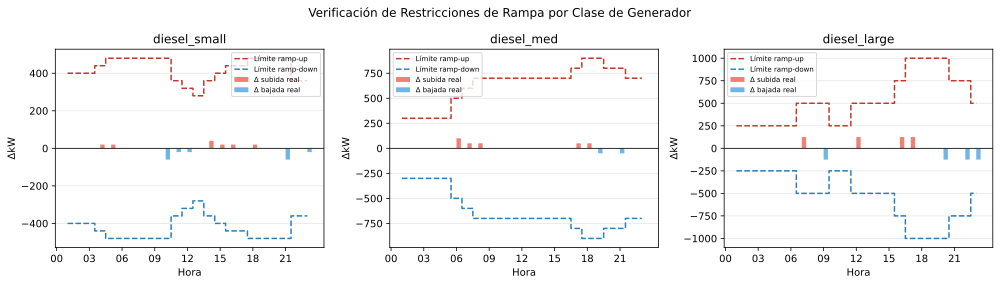


Violaciones de rampa (debe ser 0):
Clase            Ramp-up activo   Ramp-down activo
--------------------------------------------------
diesel_small                  0                  0
diesel_med                    0                  0
diesel_large                  0                  0


In [84]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Verificación de Restricciones de Rampa por Clase de Generador', fontsize=12)

for ax, g in zip(axes, GENERATORS):
    output_vals  = [pe.value(model.output[g, i])    for i in T]
    active_vals  = [int(round(pe.value(model.num_active[g, i])))  for i in T]
    startup_vals = [int(round(pe.value(model.num_startup[g, i]))) for i in T]
    shutdn_vals  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]

    delta_up = []; delta_down = []; limit_up = []; limit_down = []
    for i in range(1, len(T)):
        diff = output_vals[i] - output_vals[i-1]
        delta_up.append(max(diff, 0)); delta_down.append(max(-diff, 0))
        limit_up.append(ramp_limit[g]*active_vals[i-1] + max_output[g]*startup_vals[i])
        limit_down.append(ramp_limit[g]*active_vals[i] + max_output[g]*shutdn_vals[i])

    hours_mid = list(range(1, 24))
    ax.bar(hours_mid, delta_up,             color='#e74c3c', alpha=0.7, width=0.4, label='Δ subida real',  align='edge')
    ax.bar(hours_mid, [-d for d in delta_down], color='#3498db', alpha=0.7, width=0.4, label='Δ bajada real', align='edge')
    ax.step(hours_mid, limit_up,              color='#c0392b', lw=1.5, ls='--', where='mid', label='Límite ramp-up')
    ax.step(hours_mid, [-l for l in limit_down], color='#2980b9', lw=1.5, ls='--', where='mid', label='Límite ramp-down')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(g); ax.set_xlabel('Hora'); ax.set_ylabel('ΔkW')
    ax.set_xticks(range(0,24,3)); ax.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
    ax.legend(fontsize=7); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print('\nViolaciones de rampa (debe ser 0):')
print(f'{"Clase":<14} {"Ramp-up activo":>16} {"Ramp-down activo":>18}')
print('-'*50)
for g in GENERATORS:
    output_vals  = [pe.value(model.output[g, i]) for i in T]
    active_vals  = [int(round(pe.value(model.num_active[g, i])))  for i in T]
    startup_vals = [int(round(pe.value(model.num_startup[g, i]))) for i in T]
    shutdn_vals  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]
    n_up = n_dn = 0
    for i in range(1, len(T)):
        lim_up = ramp_limit[g]*active_vals[i-1] + max_output[g]*startup_vals[i]
        lim_dn = ramp_limit[g]*active_vals[i]   + max_output[g]*shutdn_vals[i]
        diff = output_vals[i] - output_vals[i-1]
        if diff  > lim_up + 1e-4: n_up += 1
        if -diff > lim_dn + 1e-4: n_dn += 1
    print(f'{g:<14} {n_up:>16} {n_dn:>18}')

Se observa que las barras llenas nunca superan las líneas discontinuas, verificando la factibilidad de las soluciones. Con `ramp_limit = max_output` las restricciones son trivialmente satisfechas y nunca activas.

In [85]:
print("\nEstadísticas globales:")
print(f"   Costo total óptimo    : ${costo_total:,.2f}")
print(f"   Clases generadores    : {len(GENERATORS)}")
print(f"   Períodos              : {len(T)}")
print(f"   Total unidades diesel : {sum(num_available.values())}")
print(f"   Segmentos lin.        : {N_SEG}")

total_starts = sum(int(round(pe.value(model.num_startup[g, i])))  for g in GENERATORS for i in T)
total_stops  = sum(int(round(pe.value(model.num_shutdown[g, i]))) for g in GENERATORS for i in T)
print(f"   Total arranques       : {total_starts}")
print(f"   Total apagados        : {total_stops}")
print(f"   Costo medio por kWh   : ${costo_total / sum(net_demand.values()):.4f}/kWh (sobre energía neta diesel)")
print()
print(f"── Contribución fotovoltaica ──────────────────────────────")
total_pv_energy  = sum(pv_profile.values())
total_dem_energy = sum(expected_demand.values())
print(f"   Energía FV            : {total_pv_energy:.1f} kWh/día")
print(f"   Energía diesel        : {sum(net_demand.values()):.1f} kWh/día")
print(f"   Energía total         : {total_dem_energy:.0f} kWh/día")
print(f"   Penetración FV        : {100*total_pv_energy/total_dem_energy:.1f}%")


Estadísticas globales:
   Costo total óptimo    : $7,155.30
   Clases generadores    : 3
   Períodos              : 24
   Total unidades diesel : 27
   Segmentos lin.        : 3
   Total arranques       : 31
   Total apagados        : 15
   Costo medio por kWh   : $0.2323/kWh (sobre energía neta diesel)

── Contribución fotovoltaica ──────────────────────────────
   Energía FV            : 2026.5 kWh/día
   Energía diesel        : 30798.5 kWh/día
   Energía total         : 32825 kWh/día
   Penetración FV        : 6.2%


### Análisis Económico: Costos Unitarios y Comparación de Componentes

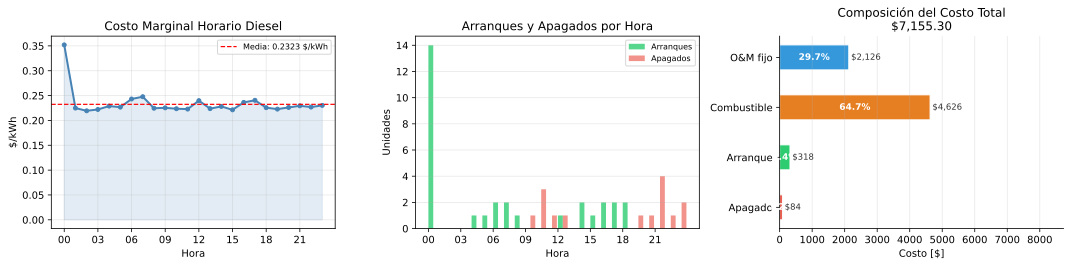


Resumen económico por clase de generador:
Clase           Energía (kWh)  Horas activo  C. Total ($)    $/kWh  Factor uso
----------------------------------------------------------------------------
diesel_small             4900           245       1896.00   0.3869       0.425
diesel_med               7300           146       2864.80   0.3924       0.304
diesel_large             5750            46       2394.50   0.4164       0.192
----------------------------------------------------------------------------
Diesel total            30798                     7155.30   0.2323
FV                     2026.5             —          0.00   0.0000              (sin costo variable)
TOTAL                   32825                     7155.30   0.2180  (sobre demanda bruta)


In [86]:
hourly_cost = period_costs.sum(axis=1).values
hourly_cost_per_kwh = hourly_cost / np.array(demand_neta_vals)   # costo diesel por kWh neto

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

ax1 = axes[0]
ax1.plot(hours, hourly_cost_per_kwh, 'steelblue', lw=2, marker='o', ms=4)
ax1.fill_between(hours, hourly_cost_per_kwh, alpha=0.15, color='steelblue')
media_kwh = costo_total / sum(net_demand.values())
ax1.axhline(media_kwh, color='red', lw=1.2, ls='--',
            label=f'Media: {media_kwh:.4f} $/kWh')
ax1.set_xlabel("Hora"); ax1.set_ylabel("$/kWh")
ax1.set_title("Costo Marginal Horario Diesel")
ax1.set_xticks(range(0,24,3)); ax1.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2 = axes[1]
starts_total = [sum(int(round(pe.value(model.num_startup[g,i])))  for g in GENERATORS) for i in T]
stops_total  = [sum(int(round(pe.value(model.num_shutdown[g,i]))) for g in GENERATORS) for i in T]
ax2.bar(hours, starts_total,               color='#2ecc71', alpha=0.8, label='Arranques', width=0.45, align='edge')
ax2.bar([h+0.45 for h in hours], stops_total, color='#e74c3c', alpha=0.6, label='Apagados', width=0.45, align='edge')
ax2.set_xlabel("Hora"); ax2.set_ylabel("Unidades")
ax2.set_title("Arranques y Apagados por Hora")
ax2.set_xticks(range(0,24,3)); ax2.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, axis='y')

ax3 = axes[2]
cost_components = {'O&M fijo': period_costs['O&M fijo'].sum(),
                   'Combustible': period_costs['Combustible'].sum(),
                   'Arranque': period_costs['Arranque'].sum(),
                   'Apagado':  period_costs['Apagado'].sum()}
wedge_colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']
labels_c = list(cost_components.keys())
values_c = list(cost_components.values())
total_c  = sum(values_c)
bars = ax3.barh(labels_c, values_c, color=wedge_colors, edgecolor='white', height=0.5)
for bar, pct, val in zip(bars, [v/total_c*100 for v in values_c], values_c):
    ax3.text(bar.get_width()/2, bar.get_y()+bar.get_height()/2,
             f'{pct:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    ax3.text(bar.get_width()+total_c*0.01, bar.get_y()+bar.get_height()/2,
             f'${val:,.0f}', ha='left', va='center', fontsize=8.5, color='#333333')
ax3.set_xlabel("Costo [$]")
ax3.set_title(f"Composición del Costo Total\n${costo_total:,.2f}")
ax3.set_xlim(0, total_c*1.22); ax3.invert_yaxis()
ax3.grid(alpha=0.3, axis='x'); ax3.spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()

print("\nResumen económico por clase de generador:")
print(f"{'Clase':<14} {'Energía (kWh)':>14} {'Horas activo':>13} {'C. Total ($)':>13} {'$/kWh':>8} {'Factor uso':>11}")
print("-" * 76)
for g in GENERATORS:
    energia  = sum(pe.value(model.output[g, i]) for i in T)
    h_activo = sum(int(round(pe.value(model.num_active[g, i]))) for i in T)
    c_tot    = solution.loc[g, 'cost_total ($)'].sum()
    max_cap  = generator_data.loc[g,'max_output'] * generator_data.loc[g,'num_available']
    f_uso    = energia / (max_cap * 24)
    print(f"{g:<14} {energia:>14.0f} {h_activo:>13d} {c_tot:>13.2f} {c_tot/energia if energia>0 else 0:>8.4f} {f_uso:>11.3f}")
print("-" * 76)
print(f"{'Diesel total':<14} {sum(net_demand.values()):>14.0f} {'':>13} {costo_total:>13.2f} {costo_total/sum(net_demand.values()):>8.4f}")
print(f"{'FV':<14} {sum(pv_profile.values()):>14.1f} {'—':>13} {'0.00':>13} {'0.0000':>8} {'':>11}  (sin costo variable)")
print(f"{'TOTAL':<14} {sum(expected_demand.values()):>14.0f} {'':>13} {costo_total:>13.2f} {costo_total/sum(expected_demand.values()):>8.4f}  (sobre demanda bruta)")

## Conclusiones

Este modelo implementa un **Unit Commitment + Despacho Económico** para una microrred diesel con generación fotovoltaica integrada, con las siguientes extensiones sobre el ejemplo original de Williams:

1. **Redimensionamiento a escala de microrred:** demanda escalada de ~45 GW a ~2,1 MW pico, con tres clases de generadores diesel de 40, 100 y 250 kW.

2. **Costos de apagado:** `num_shutdown` y `shutdown_cost` capturan los costos de detención (50% del costo de arranque, Nemati et al.).

3. **Tiempos mínimos de encendido/apagado:** restricciones MUT y MDT para evitar ciclado excesivo (Parisio, 2014).

4. **Linealización Parisio de la curva de combustible:** variable auxiliar $\sigma_{g,t}$ y restricciones de segmentos tangentes mantienen la naturaleza MILP del problema.

5. **Restricciones de rampa (V4):** formuladas con $R_g = P^{\max}_g$ (trivialmente satisfechas). Los generadores diesel tienen dinámica mucho más rápida que el paso de tiempo de 1 hora.

6. **Generación fotovoltaica — modelo Loyarte (V5):** el GFV de 400 kWp se modela en pre-proceso mediante las ecuaciones de Loyarte (ecs. 1-2). La potencia horaria $P^{\mathrm{PV}}_t$ es un parámetro determinístico calculado a partir de datos reales de irradiancia y temperatura del parque UTN FR Santa Fe (01/01/2019). La demanda que deben cubrir los generadores diesel se reduce a la demanda neta:
   $$D^{\mathrm{net}}_t = D_t - P^{\mathrm{PV}}_t$$
   La generación solar pico alcanza ~300 kW (hora 11), cubriendo el **6% de la energía diaria total**. La reserva operativa se recalcula sobre la demanda neta, reduciendo también la capacidad mínima requerida durante las horas solares. Esta integración reduce tanto el costo total de operación como el despacho de generadores diesel durante las horas centrales del día.